# Optuna: LightGBM settings

Search LightGBM settings on the same last-eight-week holdout, scored at the **display** resolution.

Set `PRODUCT` to `short` (hourly, next 24h — day model) or `medium` (6-hourly, next 7 days — week model). Trials do **not** overwrite `data/models`. Studies resume from `data/processed/optuna_{product}.db`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from energy_forecast import tune

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

PRODUCT = "short"
N_TRIALS = 20
TRAIN_SAMPLE = 0.25 if PRODUCT == "medium" else None

In [2]:
frame = tune.load_product_frame(PRODUCT)
train, holdout = tune.product_split(frame, PRODUCT, train_sample=TRAIN_SAMPLE)
print(PRODUCT, "train", len(train), "holdout", len(holdout))
print(train["timestamp"].min(), "->", train["timestamp"].max())
print("holdout", holdout["timestamp"].min(), "->", holdout["timestamp"].max())

next_hour train 80276 holdout 2689
2022-01-01 00:00:00+00:00 -> 2026-07-31 10:30:00+01:00
holdout 2026-07-31 11:00:00+01:00 -> 2026-09-25 11:00:00+01:00


## Current defaults

Score the settings already in `model.py` on this holdout so later trials have a number to beat.

In [3]:
baseline_models = tune.fit_trial(train, PRODUCT, tune.baseline_params(), refit_full=False)
baseline_mae, baseline_metrics = tune.holdout_mae(holdout, baseline_models, PRODUCT)
print("baseline params", tune.baseline_params())
baseline_metrics

baseline params {'learning_rate': 0.05, 'num_leaves': 47, 'min_child_samples': 30, 'subsample': 0.8, 'colsample_bytree': 0.8, 'n_estimators': 400}


,split,n,mae,rmse,mape,bias,pinball_10,pinball_50,pinball_90,coverage_80,interval_width,skill_vs_climatology
0,all,2689,283.4734,365.9469,0.0130,-15.8076,67.6595,141.7367,63.7095,0.7408,821.8943,0.8394


## Search

Each trial fits once (no final refit) and minimises holdout MAE. Re-run the cell to add more trials.

In [4]:
study = tune.create_study(PRODUCT)
study.optimize(tune.make_objective(train, holdout, PRODUCT), n_trials=N_TRIALS, show_progress_bar=True)
print("best MAE", study.best_value)
print("best params", study.best_params)
print("beats baseline", study.best_value < baseline_mae, "by", baseline_mae - study.best_value, "MW")

[I 2026-09-25 17:21:16,071] A new study created in RDB with name: next_hour_mae


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-25 17:21:26,253] Trial 0 finished with value: 299.22307961499985 and parameters: {'learning_rate': 0.03912720785647401, 'num_leaves': 92, 'min_child_samples': 61, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'n_estimators': 200}. Best is trial 0 with value: 299.22307961499985.
[I 2026-09-25 17:21:45,968] Trial 1 finished with value: 290.82623373660743 and parameters: {'learning_rate': 0.02219360392019892, 'num_leaves': 85, 'min_child_samples': 52, 'subsample': 0.8832290311184181, 'colsample_bytree': 0.608233797718321, 'n_estimators': 500}. Best is trial 1 with value: 290.82623373660743.
[I 2026-09-25 17:21:54,428] Trial 2 finished with value: 296.1590746633033 and parameters: {'learning_rate': 0.08887841017019547, 'num_leaves': 32, 'min_child_samples': 22, 'subsample': 0.6733618039413735, 'colsample_bytree': 0.7216968971838151, 'n_estimators': 350}. Best is trial 1 with value: 290.82623373660743.
[I 2026-09-25 17:22:01,661] Trial 3 finished with v

In [5]:
trials = study.trials_dataframe().sort_values("value")
keep = [c for c in trials.columns if c == "value" or c.startswith("params_") or c.startswith("user_attrs_")]
display(trials.loc[:, keep].head(10))

,value,params_colsample_bytree,params_learning_rate,params_min_child_samples,params_n_estimators,params_num_leaves,params_subsample,user_attrs_coverage_80,user_attrs_interval_width,user_attrs_skill_vs_climatology
17,264.4144,0.9580,0.0398,50,500,94,0.7115,0.7765,827.9833,0.8502
12,264.5665,0.9493,0.0426,76,500,91,0.7396,0.7642,820.9058,0.8501
10,265.2073,0.9686,0.0820,63,500,92,0.8337,0.7717,842.5425,0.8497
18,265.2934,0.9949,0.0346,45,500,95,0.6697,0.7661,831.9797,0.8497
19,266.8179,0.9797,0.0479,38,500,88,0.8069,0.7780,842.4346,0.8488
15,266.8427,0.8956,0.0801,69,450,87,0.9052,0.7743,863.0461,0.8488
13,267.0076,0.9577,0.0653,66,400,87,0.7336,0.7802,843.6084,0.8487
14,268.1110,0.9248,0.0286,78,500,84,0.7260,0.7735,906.8560,0.8481
11,270.2325,0.9669,0.0456,80,500,52,0.8276,0.7713,837.7171,0.8469
16,272.8064,0.8798,0.0994,79,450,91,0.7585,0.7586,858.1079,0.8454


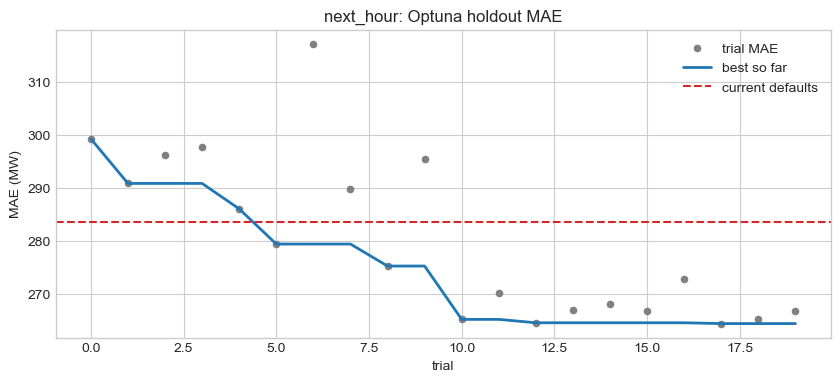

In [6]:
history = study.trials_dataframe().dropna(subset=["value"]).sort_values("number")
history["best_so_far"] = history["value"].cummin()
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(history["number"], history["value"], color="0.5", s=20, label="trial MAE")
ax.plot(history["number"], history["best_so_far"], color="tab:blue", linewidth=2, label="best so far")
ax.axhline(baseline_mae, color="tab:red", linestyle="--", label="current defaults")
ax.set_title(f"{PRODUCT}: Optuna holdout MAE")
ax.set_xlabel("trial")
ax.set_ylabel("MAE (MW)")
ax.legend()
plt.show()

## Confirm the winner

Refit the best trial the same way production does (`refit_full=True`) and compare to the baseline. Copy the printed dict into `LGB_MEAN` / `LGB_RESIDUAL` in `model.py` and re-run notebook 03 if you want to keep it.

In [7]:
best_models = tune.fit_trial(train, PRODUCT, study.best_params, refit_full=True)
best_mae, best_metrics = tune.holdout_mae(holdout, best_models, PRODUCT)
compare = pd.concat(
    [baseline_metrics.assign(split="current defaults"), best_metrics.assign(split="optuna best")],
    ignore_index=True,
)
display(compare)
print("Paste into model.py:")
print(study.best_params)

,split,n,mae,rmse,mape,bias,pinball_10,pinball_50,pinball_90,coverage_80,interval_width,skill_vs_climatology
0,current defaults,2689,283.4734,365.9469,0.0130,-15.8076,67.6595,141.7367,63.7095,0.7408,821.8943,0.8394
1,optuna best,2689,263.1557,336.9659,0.0121,-9.4038,62.2336,131.5779,60.4053,0.7784,834.6918,0.8509


Paste into model.py:
{'learning_rate': 0.03982989749645549, 'num_leaves': 94, 'min_child_samples': 50, 'subsample': 0.7114944926320207, 'colsample_bytree': 0.9579950564911175, 'n_estimators': 500}
